# Chapter 4 — Regression and Prediction

**Book:** Practical Statistics for Data Scientists, 2nd Edition  
**Name:** Rainaldi Pakpahan  
**NIM:** 101032300084  
**Class:** TK 47-04  

**Name:**Firdaus Arif Ramadhani  
**NIM:** 101032300131  
**Class:** TK 47-04  

## Tujuan

Chapter ini membahas regresi sebagai metode untuk memahami hubungan
antara variabel dan melakukan prediksi. Pembahasan meliputi simple
linear regression, multiple regression, residual, evaluasi model,
dan prediksi.

## Alur Pembahasan

1. Menyiapkan dataset
2. Simple Linear Regression
3. Koefisien regresi
4. Prediksi nilai
5. Residual
6. Evaluasi model
7. Multiple Linear Regression
8. Membandingkan nilai aktual dan prediksi
9. Analisis residual
10. Kesimpulan

In [48]:
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)

print("Library berhasil dimuat.")

Library berhasil dimuat.


### Interpretasi

Library berhasil dimuat dan siap digunakan untuk membuat model
regresi, melakukan prediksi, serta mengevaluasi hasil model.

## 1. Menyiapkan Dataset

Pada chapter ini digunakan dataset `LungDisease.csv` sebagai contoh
untuk memahami hubungan antara exposure dan nilai PEFR menggunakan
regresi linear sederhana.

In [49]:
REPO_DIR = Path("/content/practical-statistics-for-data-scientists")
REPO_URL = "https://github.com/gedeck/practical-statistics-for-data-scientists.git"

if not REPO_DIR.exists():
    subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
        check=True
    )

DATA_DIR = REPO_DIR / "data"

print("Lokasi dataset:")
print(DATA_DIR)

Lokasi dataset:
/content/practical-statistics-for-data-scientists/data


In [50]:
lung = pd.read_csv(DATA_DIR / "LungDisease.csv")

print("Ukuran dataset:", lung.shape)
lung.head()

Ukuran dataset: (122, 2)


,PEFR,Exposure
0,390,0
1,410,0
2,430,0
3,460,0
4,420,1


### Interpretasi

Dataset terdiri dari 122 observasi dan 2 variabel, yaitu PEFR dan Exposure.
Keduanya bertipe numerik dan tidak memiliki missing value pada data yang ditampilkan.

In [51]:
lung.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   PEFR      122 non-null    int64
 1   Exposure  122 non-null    int64
dtypes: int64(2)
memory usage: 2.0 KB


In [52]:
lung.describe()

,PEFR,Exposure
count,122.000,122.000
mean,365.656,14.082
std,105.133,6.960
min,110.000,0.000
25%,300.000,7.000
50%,365.000,17.000
75%,430.000,20.000
max,610.000,23.000


### Interpretasi

Rata-rata PEFR adalah sekitar 365.656, sedangkan rata-rata Exposure
sekitar 14.082. Nilai PEFR memiliki penyebaran yang cukup besar,
dengan minimum 110 dan maksimum 610.

## 2. Simple Linear Regression

Simple linear regression digunakan untuk melihat hubungan antara satu
variabel prediktor dan satu variabel target.

Pada contoh ini:
- Exposure digunakan sebagai variabel prediktor
- PEFR digunakan sebagai variabel target

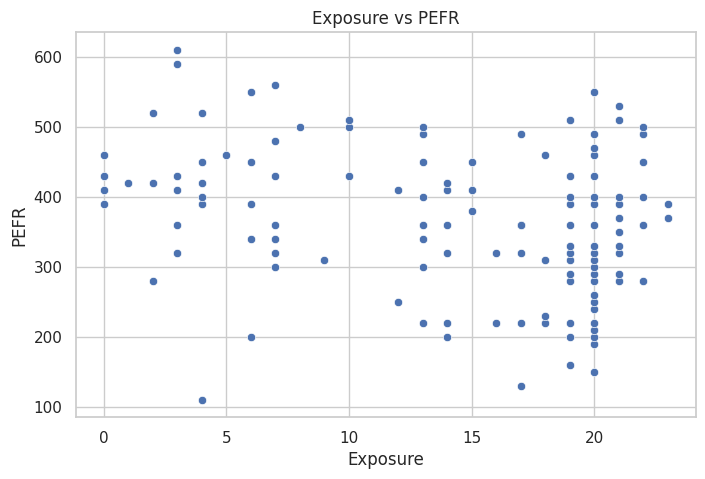

In [53]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=lung,
    x="Exposure",
    y="PEFR"
)

plt.title("Exposure vs PEFR")
plt.show()

### Interpretasi

Scatter plot digunakan untuk melihat pola hubungan antara Exposure
dan PEFR. Arah penyebaran titik dapat memberi gambaran apakah terdapat
hubungan linear antara kedua variabel.

In [54]:
X = lung[["Exposure"]]
y = lung["PEFR"]

model = LinearRegression()
model.fit(X, y)

print("Intercept :", model.intercept_)
print("Coefficient :", model.coef_[0])

Intercept : 424.582806573957
Coefficient : -4.184576485461442


### Interpretasi

Intercept sebesar 424.583 menunjukkan prediksi PEFR ketika Exposure = 0.
Koefisien -4.185 menunjukkan bahwa setiap kenaikan 1 unit Exposure
diperkirakan menurunkan PEFR sekitar 4.185.

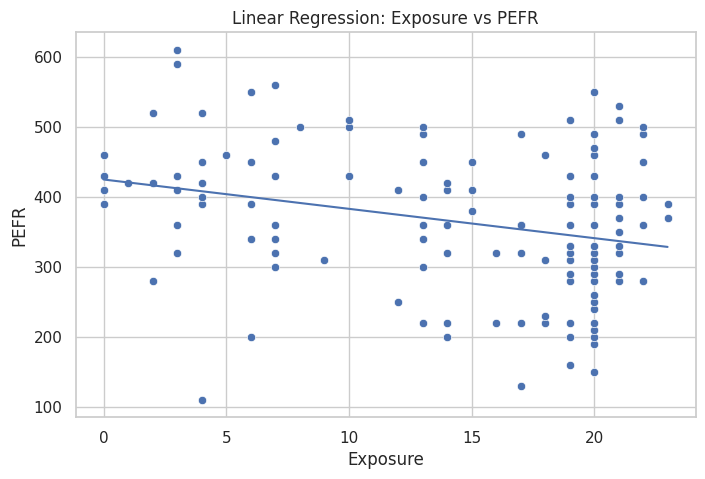

In [55]:
lung["Predicted_PEFR"] = model.predict(X)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=lung,
    x="Exposure",
    y="PEFR"
)

plt.plot(
    lung["Exposure"],
    lung["Predicted_PEFR"]
)

plt.title("Linear Regression: Exposure vs PEFR")
plt.show()

### Interpretasi

Garis regresi menunjukkan nilai PEFR yang diprediksi berdasarkan
Exposure. Semakin dekat titik data dengan garis, semakin kecil
kesalahan prediksi pada observasi tersebut.

### Interpretasi

Garis regresi menurun dari kiri ke kanan, sehingga menunjukkan hubungan
negatif antara Exposure dan PEFR.

In [56]:
new_data = pd.DataFrame({
    "Exposure": [5, 10, 15]
})

predictions = model.predict(new_data)

prediction_table = new_data.copy()
prediction_table["Predicted_PEFR"] = predictions

prediction_table

,Exposure,Predicted_PEFR
0,5,403.660
1,10,382.737
2,15,361.814


### Interpretasi

Nilai PEFR yang diprediksi menurun ketika Exposure meningkat.
Hal ini konsisten dengan koefisien regresi yang bernilai negatif.

## 4. Residual

Residual adalah selisih antara nilai aktual dan nilai yang diprediksi
oleh model.

Residual = Actual - Predicted

In [57]:
lung["Residual"] = (
    lung["PEFR"] - lung["Predicted_PEFR"]
)

lung[
    ["Exposure", "PEFR", "Predicted_PEFR", "Residual"]
].head()

,Exposure,PEFR,Predicted_PEFR,Residual
0,0,390,424.583,-34.583
1,0,410,424.583,-14.583
2,0,430,424.583,5.417
3,0,460,424.583,35.417
4,1,420,420.398,-0.398


### Interpretasi

Residual menunjukkan selisih antara nilai PEFR aktual dan prediksi.
Nilai yang mendekati nol menunjukkan prediksi yang lebih dekat dengan
nilai sebenarnya.

## 5. Evaluasi Model

Model dapat dievaluasi menggunakan R² dan Root Mean Squared Error
(RMSE).

R² menunjukkan seberapa besar variasi target yang dapat dijelaskan
oleh model, sedangkan RMSE menunjukkan rata-rata besarnya kesalahan
prediksi.

In [58]:
r2 = r2_score(
    lung["PEFR"],
    lung["Predicted_PEFR"]
)

rmse = np.sqrt(
    mean_squared_error(
        lung["PEFR"],
        lung["Predicted_PEFR"]
    )
)

print(f"R-squared : {r2:.3f}")
print(f"RMSE      : {rmse:.3f}")

R-squared : 0.077
RMSE      : 100.603


### Interpretasi

R-squared sebesar 0.077 menunjukkan bahwa model hanya menjelaskan sekitar
7.7% variasi PEFR. RMSE sebesar 100.603 menunjukkan kesalahan prediksi
masih cukup besar.

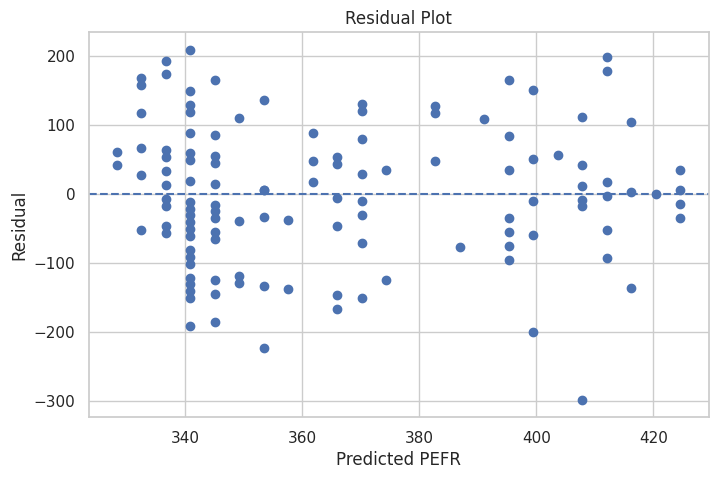

In [59]:
plt.figure(figsize=(8, 5))

plt.scatter(
    lung["Predicted_PEFR"],
    lung["Residual"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted PEFR")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

### Interpretasi

Residual plot digunakan untuk melihat pola kesalahan model. Model
linear yang baik biasanya memiliki residual yang tersebar di sekitar
nilai nol tanpa pola yang terlalu jelas.

## 6. Multiple Linear Regression

Multiple linear regression menggunakan lebih dari satu variabel
prediktor untuk memperkirakan nilai target.

Pada bagian ini, harga rumah (`AdjSalePrice`) diprediksi menggunakan
beberapa karakteristik rumah seperti luas bangunan, luas tanah,
jumlah kamar mandi, dan jumlah kamar tidur.

In [69]:
house = pd.read_csv(
    DATA_DIR / "house_sales.csv",
    sep="\t"
)

print("Ukuran dataset:", house.shape)
house.head()

Ukuran dataset: (22687, 22)


,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,SqFtTotLiving,SqFtFinBasement,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.931,"300,805.000",2,9373,2400,0,3.000,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929,"1,076,162.000",1,20156,3764,1452,3.750,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.978,"761,805.000",1,26036,2060,900,1.750,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961,"442,065.000",1,8618,3200,1640,3.750,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.808,"297,065.000",1,8620,1720,0,1.750,4,7,1948,0,0,104000,205000,98168,False


### Interpretasi

Dataset house sales berhasil dimuat dengan 22.687 observasi dan
22 variabel. Beberapa variabel akan digunakan sebagai prediktor
untuk memperkirakan harga rumah.

In [63]:
house_model = house[
    [
        "AdjSalePrice",
        "SqFtTotLiving",
        "SqFtLot",
        "Bathrooms",
        "Bedrooms"
    ]
].dropna()

house_model.head()

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms
1,"300,805.000",2400,9373,3.000,6
2,"1,076,162.000",3764,20156,3.750,4
3,"761,805.000",2060,26036,1.750,4
4,"442,065.000",3200,8618,3.750,5
5,"297,065.000",1720,8620,1.750,4


### Interpretasi

Data yang digunakan terdiri dari harga rumah sebagai target serta
empat variabel prediktor, yaitu luas bangunan, luas tanah, jumlah
kamar mandi, dan jumlah kamar tidur.

In [70]:
X_multi = house_model[
    [
        "SqFtTotLiving",
        "SqFtLot",
        "Bathrooms",
        "Bedrooms"
    ]
]

y_multi = house_model["AdjSalePrice"]

multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

coefficients = pd.Series(
    multi_model.coef_,
    index=X_multi.columns
)

print("Intercept:")
print(multi_model.intercept_)

print("\nCoefficients:")
print(coefficients)

Intercept:
96960.38147618528

Coefficients:
SqFtTotLiving       327.825
SqFtLot              -0.085
Bathrooms        13,256.964
Bedrooms        -71,714.785
dtype: float64


### Interpretasi

Setiap koefisien menunjukkan perubahan prediksi harga rumah ketika
satu variabel meningkat satu unit dan variabel lainnya dianggap tetap.

Koefisien positif menunjukkan kecenderungan meningkatkan harga,
sedangkan koefisien negatif menunjukkan kecenderungan menurunkan
harga prediksi.

## 7. Membandingkan Nilai Aktual dan Prediksi

Nilai aktual dan hasil prediksi dibandingkan untuk melihat seberapa
dekat model dalam memperkirakan harga rumah sebenarnya.

In [65]:
house_model["Predicted_Price"] = multi_model.predict(X_multi)

house_model[
    ["AdjSalePrice", "Predicted_Price"]
].head(10)

,AdjSalePrice,Predicted_Price
1,"300,805.000","492,429.423"
2,"1,076,162.000","1,092,042.203"
3,"761,805.000","506,416.080"
4,"442,065.000","836,411.077"
5,"297,065.000","396,430.381"
6,"411,781.000","278,208.046"
7,"380,785.000","472,476.977"
8,"349,489.000","441,814.499"
9,"231,239.000","290,883.914"
10,"463,148.000","484,812.782"


### Interpretasi

Nilai predicted price merupakan hasil estimasi model. Beberapa hasil
prediksi cukup dekat dengan harga aktual, sedangkan beberapa lainnya
masih memiliki selisih yang cukup besar.

In [66]:
multi_r2 = r2_score(
    y_multi,
    house_model["Predicted_Price"]
)

multi_rmse = np.sqrt(
    mean_squared_error(
        y_multi,
        house_model["Predicted_Price"]
    )
)

print(f"R-squared : {multi_r2:.3f}")
print(f"RMSE      : {multi_rmse:,.2f}")

R-squared : 0.501
RMSE      : 272,275.57


### Interpretasi

R-squared sebesar 0.501 menunjukkan bahwa model mampu menjelaskan
sekitar 50.1% variasi harga rumah. RMSE sebesar 272,275.57 menunjukkan
masih terdapat kesalahan prediksi yang cukup besar.

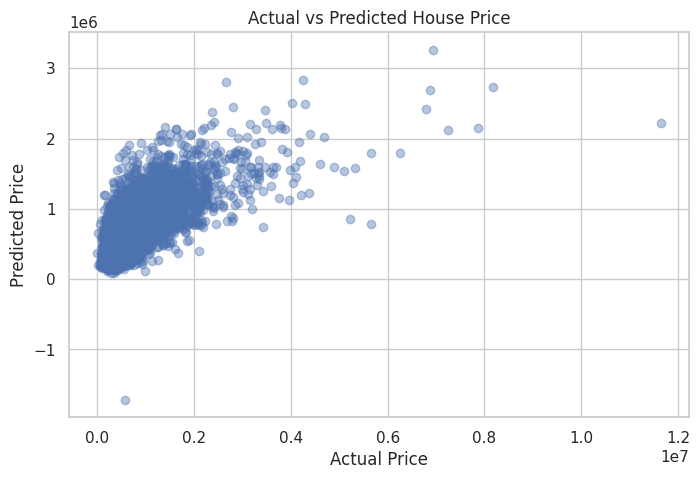

In [67]:
plt.figure(figsize=(8, 5))

plt.scatter(
    house_model["AdjSalePrice"],
    house_model["Predicted_Price"],
    alpha=0.4
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")

plt.show()

### Interpretasi

Grafik menunjukkan hubungan positif antara harga aktual dan harga
prediksi. Namun, masih terdapat beberapa titik yang jauh dari pola
utama sehingga prediksi belum sepenuhnya akurat.

## 8. Analisis Residual

Residual merupakan selisih antara harga aktual dan harga yang
diprediksi oleh model.

Residual digunakan untuk melihat pola kesalahan prediksi pada
multiple linear regression.

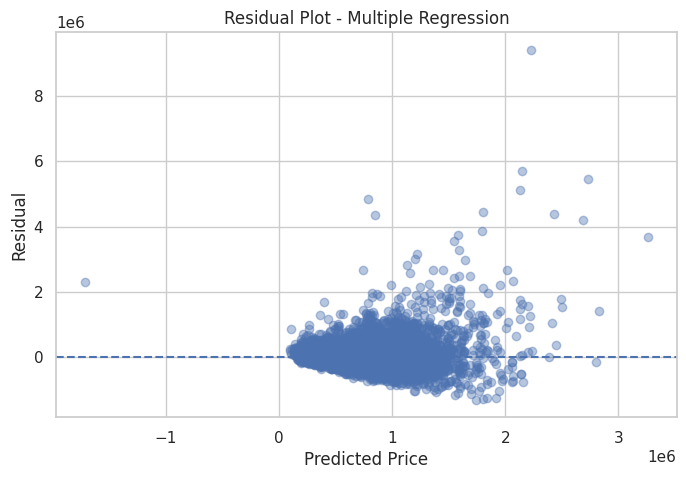

In [68]:
house_model["Residual"] = (
    house_model["AdjSalePrice"]
    - house_model["Predicted_Price"]
)

plt.figure(figsize=(8, 5))

plt.scatter(
    house_model["Predicted_Price"],
    house_model["Residual"],
    alpha=0.4
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot - Multiple Regression")

plt.show()

### Interpretasi

Residual tersebar di sekitar garis nol, tetapi penyebarannya semakin
besar pada harga prediksi yang tinggi. Hal ini menunjukkan bahwa
kesalahan model cenderung meningkat untuk rumah dengan harga tinggi.

## 9. Ringkasan Chapter 4

Pada chapter ini telah digunakan simple linear regression dan
multiple linear regression untuk mempelajari hubungan antarvariabel
dan melakukan prediksi.

Simple linear regression menggunakan satu variabel prediktor,
sedangkan multiple linear regression menggunakan beberapa variabel.
Residual, R-squared, dan RMSE digunakan untuk mengevaluasi hasil model.

## 10. Kesimpulan

Regression dapat digunakan untuk memahami hubungan antara variabel
prediktor dan target serta menghasilkan nilai prediksi.

Pada simple linear regression, Exposure memiliki hubungan negatif
dengan PEFR. Pada multiple linear regression, beberapa karakteristik
rumah digunakan untuk memperkirakan harga rumah.

Hasil evaluasi menunjukkan bahwa model masih memiliki kesalahan
prediksi, sehingga evaluasi model tetap penting sebelum hasil
digunakan lebih lanjut.

## 11. Referensi

Bruce, P., Bruce, A., & Gedeck, P. (2020).
*Practical Statistics for Data Scientists: 50+ Essential Concepts
Using R and Python*. 2nd Edition. O'Reilly Media.

Repository kode dan dataset:
https://github.com/gedeck/practical-statistics-for-data-scientists